In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
# Set random seed for reproducibility
np.random.seed(42)

# RANSAC: Robust Estimation for Computer Vision

In this session, we will learn about the RANSAC (RANdom SAmple Consensus) algorithm, a robust method for fitting models in the presence of outliers.

## 1. Introduction and Motivation

In many real-world problems (e.g., feature matching in images, model fitting), the data contains a significant number of outliers. Outliers can greatly affect the performance of standard fitting methods like least squares.

RANSAC provides a robust alternative by:

- Randomly sampling subsets of the data
- Fitting a model to each subset
- Evaluating how many data points agree with the fitted model (inliers)

The model with the highest consensus is chosen as the best estimate.

First let's see some outlier examples

### 1.1 Outlier Examples

#### 1.1.1 Line Fitting

In [ ]:
def plot_line(x_inliers, y_inliers, x_outliers, y_outliers):
    # Plot the synthetic data
    plt.figure(figsize=(8, 6))
    plt.scatter(x_inliers, y_inliers, color='blue', label='Inliers')
    if len(x_outliers) > 0:
        plt.scatter(x_outliers, y_outliers, color='red', label='Outliers')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Synthetic Data with Inliers and Outliers')
    plt.show()

Let's define a line y = 0.5x + 2

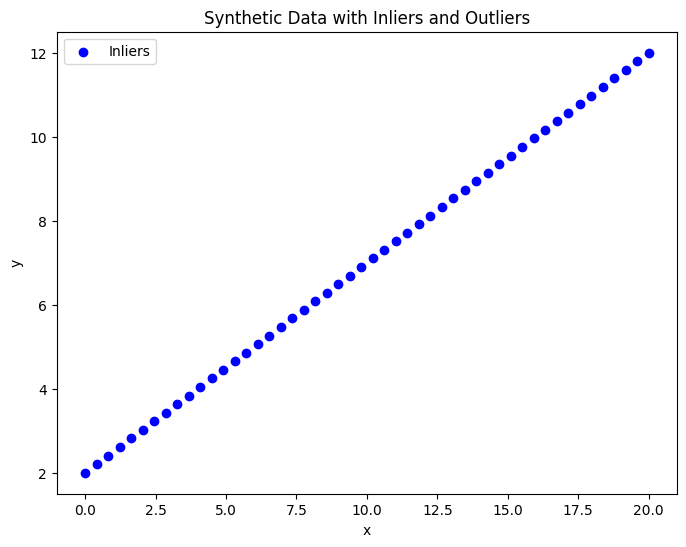

In [ ]:
# Generate inlier data along a line: y = 0.5*x + 2
n_inliers = 50
x_inliers = np.linspace(0, 20, n_inliers)
y_inliers = 0.5 * x_inliers + 2

plot_line(x_inliers, y_inliers, [], [])

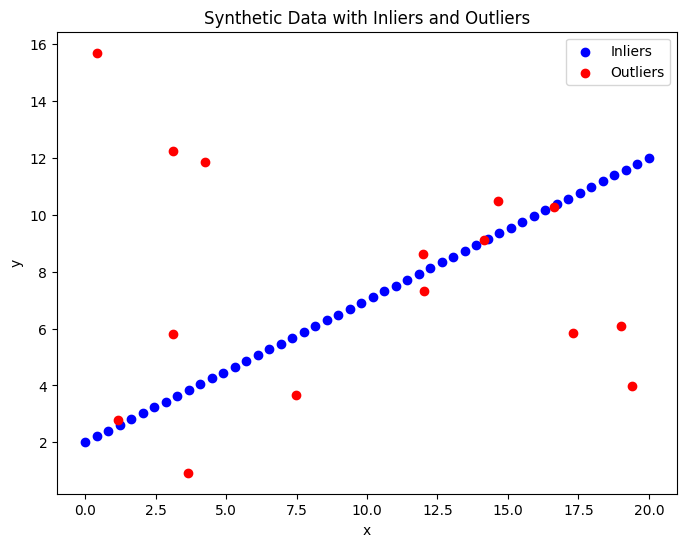

In [ ]:
# Generate outlier data
n_outliers = 15
x_outliers = np.random.uniform(0, 20, n_outliers)
y_outliers = np.random.uniform(0, 20, n_outliers)

# Combine the data
x = np.concatenate((x_inliers, x_outliers))
y = np.concatenate((y_inliers, y_outliers))

points = np.vstack((x, y)).T

plot_line(x_inliers, y_inliers, x_outliers, y_outliers)

#### 1.1.2 Regular Method for Line Fitting - Least Square

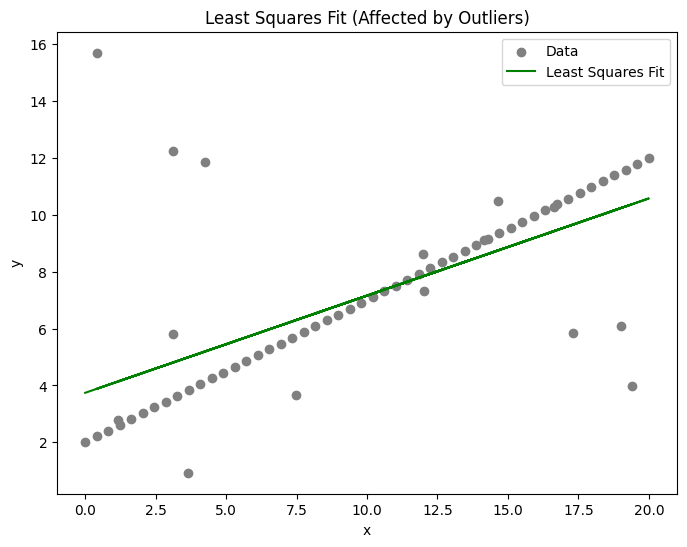

Least Squares Coefficients: slope = 0.34, intercept = 3.74


In [ ]:
# you may not have this module installed. If not, use pip install scikit-learn
from sklearn.linear_model import LinearRegression

# Reshape x for sklearn
X = x.reshape(-1, 1)

# Fit linear regression
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)

# Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='gray', label='Data')
plt.plot(x, y_pred, color='green', label='Least Squares Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Least Squares Fit (Affected by Outliers)')
plt.show()

print(f"Least Squares Coefficients: slope = {lr.coef_[0]:.2f}, intercept = {lr.intercept_:.2f}")

### 1.2 Feature Matching

We can also see some more computer-vision related outlier example

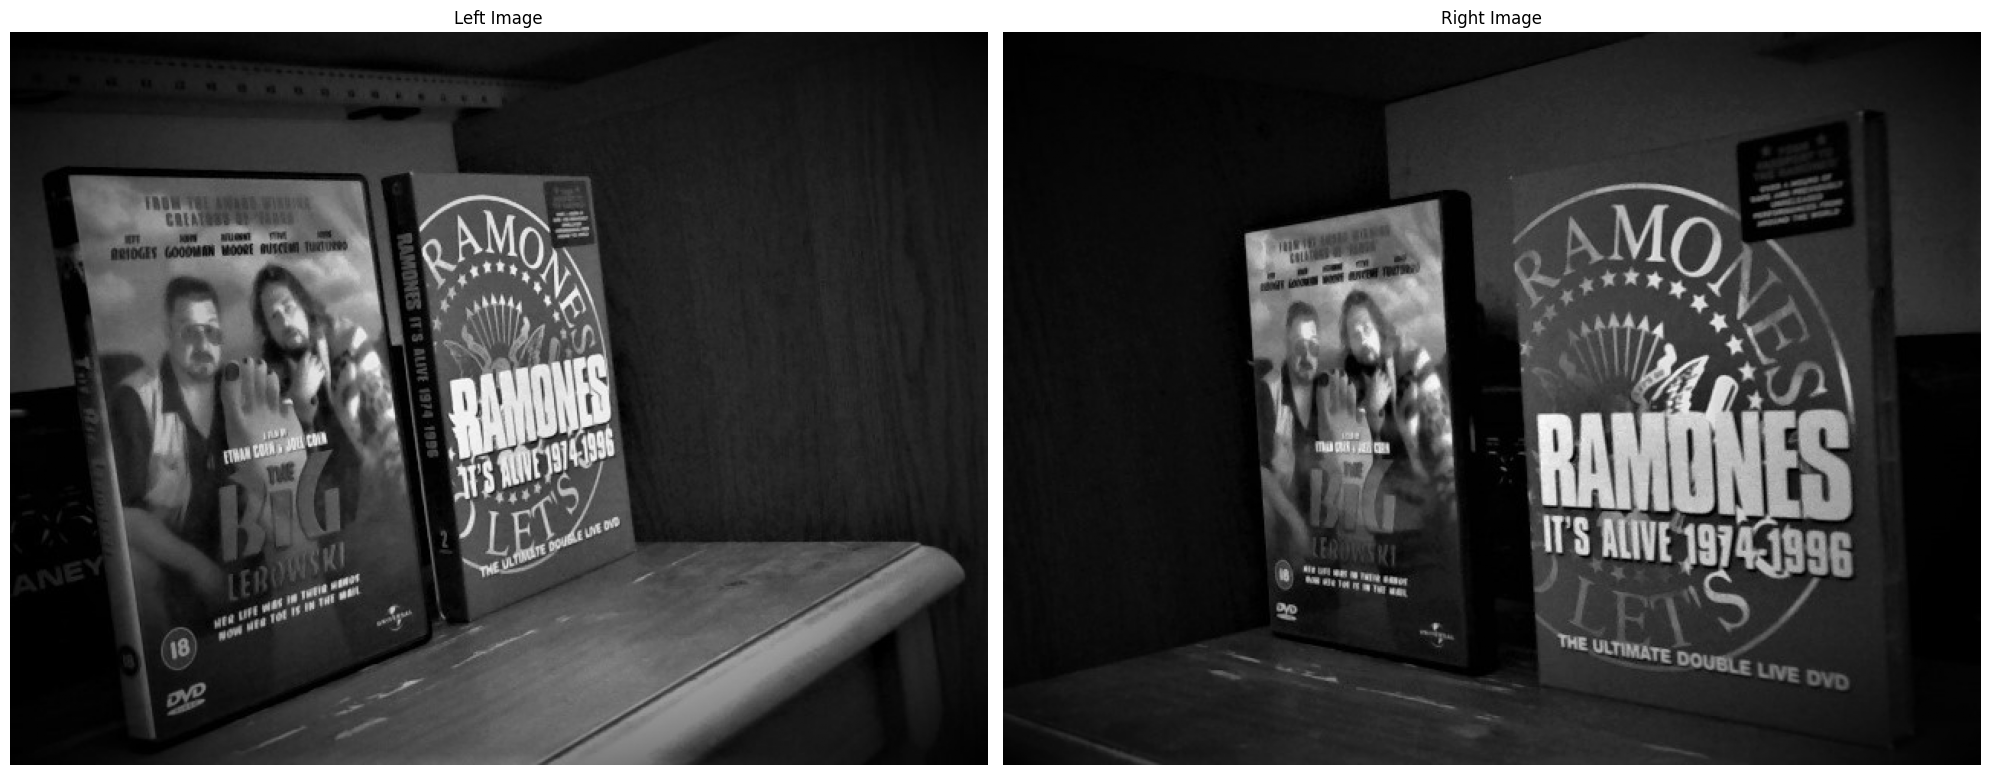

In [ ]:
# img_left_dist = cv2.imread('image_l.jpg', 0)
# img_right_dist = cv2.imread('image_r.jpg', 0)

# plt.figure(figsize = (20, 10))
# plt.imshow(img_left_dist);

img_left_dist = cv2.imread('image_l.jpg', 0)
img_right_dist = cv2.imread('image_r.jpg', 0)

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(img_left_dist, cmap='gray')
plt.title('Left Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_right_dist, cmap='gray')
plt.title('Right Image')
plt.axis('off')

plt.tight_layout()
plt.show()

##### Feature Detection, Matching and Visualization

**Optional Notes**: Note that in the matching process, after we utlize brute force matching, we conduct ratio test.
The ratio test is proposed by D.Lowe in his paper to be used with KNN matching.

In general, it’s done
like this: each keypoint of the left image is matched with a number of keypoints from the right image
and we only keep the 2 best matches for each keypoint of the left. Smaller the distance, better the
match. Then we only keep a match if for this keypoint its best distance is smaller than 0.75 times the
distance of the second best match.


In [ ]:
def feature_matching(img_left, img_right):
    '''
    Input:
    img_left - An image read by OpenCV's imread
    img_right - An image read by OpenCV's imread

    Output:
    points_left - array of tuples. Each tuple is a coordinate on the left image.
    points_right - array of tuples. Each tuple is a coordinate on the right image.
    '''
    # generate SIFT feature
    feature_detector = cv2.SIFT_create()
    keypoints_left, descriptors_left = feature_detector.detectAndCompute(img_left, None)
    keypoints_right, descriptors_right = feature_detector.detectAndCompute(img_right, None)

    # construct BFMatcher
    bf_matcher = cv2.BFMatcher()
    matches = bf_matcher.knnMatch(descriptors_left,descriptors_right, k=2)

    # apply ratio test
    good_matches = []
    for best, second in matches:
        if best.distance < 0.8*second.distance:
            # here we are converting it to a list to do visualization.
            # I'm not sure why we need this but not doing so will make visualization fail
            good_matches.append([best])


    # convert OpenCV's special match class to regular array
    points_left = []
    points_right = []
    for best in good_matches:
        points_left.append(keypoints_left[best[0].queryIdx].pt)
        points_right.append(keypoints_right[best[0].trainIdx].pt)


    # some visualization
    img_matches = cv2.drawMatchesKnn(img_left, keypoints_left,
                                     img_right,keypoints_right,
                                     good_matches[:20],None,
                                     flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    plt.figure(figsize = (20, 10))
    plt.imshow(img_matches);
    return points_left, points_right

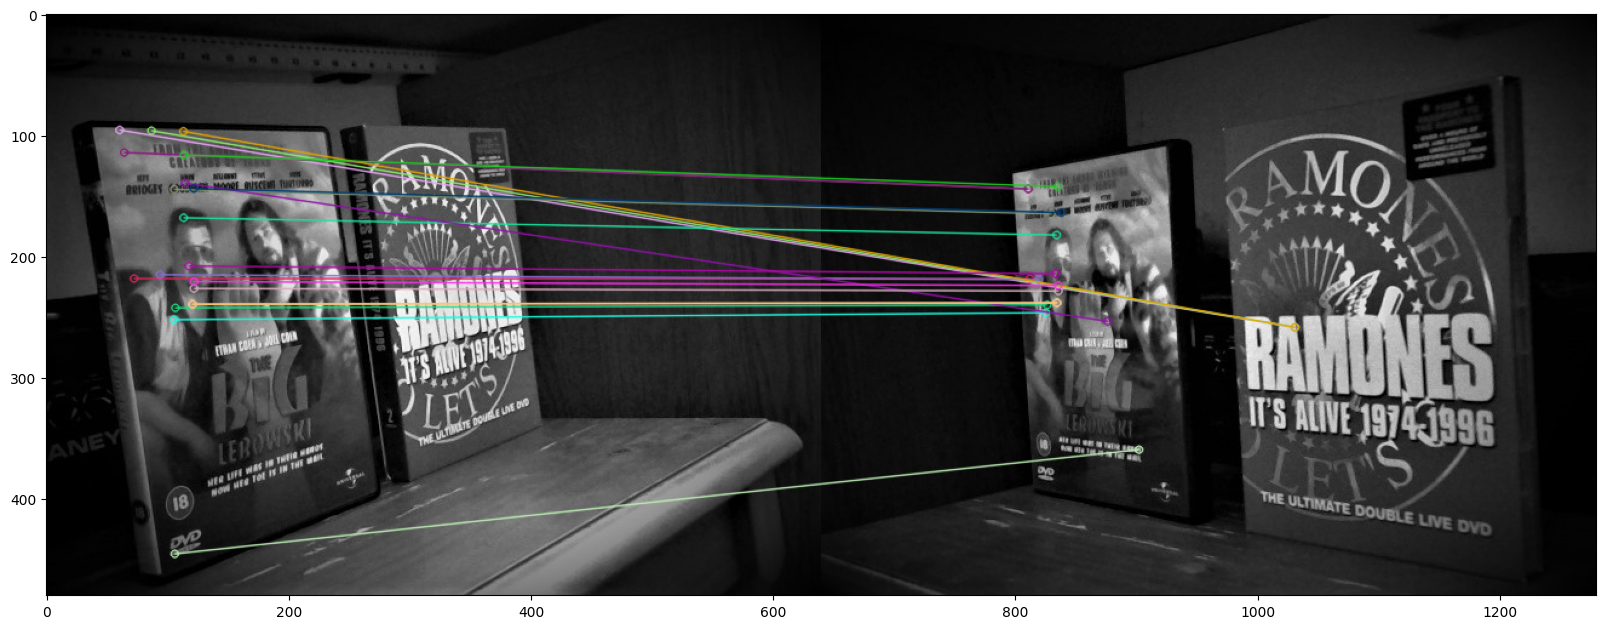

In [ ]:
points_left_dist, points_right_dist = feature_matching(img_left_dist, img_right_dist)

As you can see, we have tons of SIFT matching on these two images. A lot of them are frankly terrible matches. Later on, we will see how they fare when we do fundamental matrix estimation using them.

### 1.3 RANSAC

As a reminder, RANSAC is basically three steps in a loop:
- Randomly sampling subsets of the data
- Fitting a model to each subset
- Evaluating how many data points agree with the fitted model (inliers)

In this case of line fitting, what's a model?

#### 1.3.1 Helper Functions

##### Plotting

In [ ]:
from IPython.display import display, clear_output
def plot_iteration(points, sample_idxs, iteration, m, b, inlier_idxs=None):
    fig = plt.figure()
    ax = fig.add_subplot(111)

    ax.scatter(points[:, 0], points[:, 1], color='gray', label='Data')
    # Mark the two sampled points
    if sample_idxs is not None:
        ax.scatter(points[sample_idxs, 0], points[sample_idxs, 1],
                    color='green', marker='x', s=100, label='Sampled Points')
    # Plot the candidate line
    x_vals = np.array([points[:, 0].min(), points[:, 0].max()])
    y_vals = m * x_vals + b
    ax.plot(x_vals, y_vals, color='red', linewidth=2, label='Candidate Line')
    # Highlight the inliers
    if inlier_idxs:
        ax.scatter(points[inlier_idxs, 0], points[inlier_idxs, 1], color='blue', label='Inliers')
    if iteration is not None:
        ax.set_title(f"Iteration {iteration+1}: y = {m:.2f}x + {b:.2f} | Inliers: {len(inlier_idxs)}")
    else:
        ax.set_title(f"Final Model: y = {m:.2f}x + {b:.2f} | Inliers: {len(inlier_idxs)}")


    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(points[:, 0].min() - 1, points[:, 0].max() + 1)
    ax.set_ylim(points[:, 1].min() - 1, points[:, 1].max() + 1)
    display(fig)
    clear_output(wait=True)
    plt.pause(0.2)

##### Calculating a Model

In the case of line fitting, the model is simply a line. Because in the end we want to find a line, and only with respect to a line, we can talk about inliers/outliers

In [ ]:
def compute_line_model(p1, p2):
    """
    Given two points p1 and p2 (each a 2D point), compute the parameters of the line
    in the form: y = m*x + b.
    Returns: slope m and intercept b.
    """
    # Avoid division by zero if the x values are nearly the same
    if np.abs(p2[0] - p1[0]) < 1e-6:
        return None  # Invalid model
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    b = p1[1] - m * p1[0]
    return m, b

def compute_distance(point, m, b):
    """
    Compute the perpendicular distance from a point to the line y = m*x + b.
    """
    x0, y0 = point
    return np.abs(m * x0 - y0 + b) / np.sqrt(m**2 + 1)


#### 1.3.2 RANSAC Implementation, a First Attempt

In [ ]:
def simple_ransac(points, num_iterations=100, threshold=2.0, plot=True):
    """
    Step through the RANSAC algorithm one iteration at a time.

    For each iteration, two random points are chosen to compute a candidate model.
    The candidate's inliers (points within the threshold) are determined, and the
    candidate line is plotted along with the data. Press Enter to proceed to the next step.
    """
    best_model = None
    best_inlier_idxs = []

    for i in range(num_iterations):
        # Randomly select 2 distinct points
        sample_idxs = np.random.choice(points.shape[0], 2, replace=False)
        p1, p2 = points[sample_idxs[0]], points[sample_idxs[1]]

        # Compute the line model from the two points
        candidate_model = compute_line_model(p1, p2)
        m, b = candidate_model

        # Determine inliers for the candidate model
        inlier_idxs = []
        for idx in range(points.shape[0]):
            distance = compute_distance(points[idx], m, b)
            if distance < threshold:
                inlier_idxs.append(idx)

        # Check if this candidate is the best so far

        if len(inlier_idxs) > len(best_inlier_idxs):
            best_inlier_idxs = inlier_idxs
            best_model = candidate_model
        if plot:
            plot_iteration(points=points, sample_idxs=sample_idxs, iteration=i, m=m, b=b, inlier_idxs=inlier_idxs)
            input("Press Enter")

    if best_model is not None:
        print(f"\nBest candidate over {num_iterations} iterations: y = {best_model[0]:.2f}x + {best_model[1]:.2f} with {len(best_inlier_idxs)} inliers.")
        return best_model, best_inlier_idxs
    else:
        print("No valid model was found.")
        return None, None

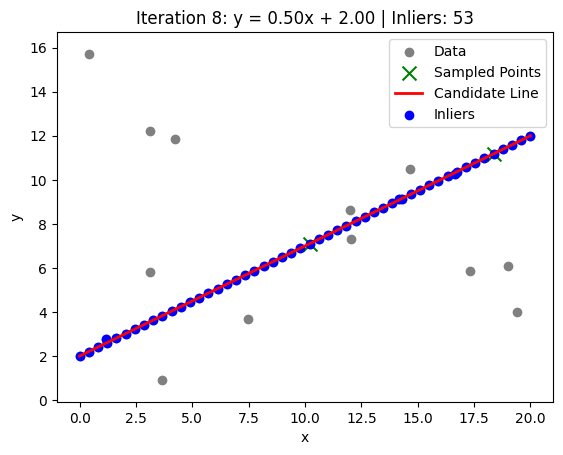

In [ ]:
model, inlier_idxs = simple_ransac(points, num_iterations=10, threshold=0.5, plot=True)

In [ ]:
if model is not None:
    m, b = model
    print(f"Simple RANSAC Model: y = {m:.2f} * x + {b:.2f}")
    print(f"Number of inliers: {len(inlier_idxs)} out of {points.shape[0]}")
else:
    print("Simple RANSAC did not find a satisfactory model.")
# Plot the results
plot_iteration(points=points, sample_idxs=None, iteration=None, m=m, b=b, inlier_idxs=inlier_idxs)

#### 1.3.3 More Challenging Scenario

Let's make things even more challenging. Now we not only have outliers, our data is also noisy

In [ ]:
# Generate noisy inlier data along a line: y = 0.5*x + 2
n_inliers = 50
x_inliers = np.linspace(0, 20, n_inliers)
y_inliers = 0.5 * x_inliers + 2 + np.random.normal(scale=1.0, size=n_inliers)

n_outliers = 15
x_outliers = np.random.uniform(0, 20, n_outliers)
y_outliers = np.random.uniform(0, 20, n_outliers)

# Combine the data
x = np.concatenate((x_inliers, x_outliers))
y = np.concatenate((y_inliers, y_outliers))

points = np.vstack((x, y)).T

plot_line(x_inliers, y_inliers, x_outliers, y_outliers)

In [ ]:
model, inlier_idxs = simple_ransac(points, num_iterations=1000, threshold=0.5, plot=False)
if model is not None:
    m, b = model
    print(f"Simple RANSAC Model: y = {m:.2f} * x + {b:.2f}")
    print(f"Number of inliers: {len(inlier_idxs)} out of {points.shape[0]}")
else:
    print("Simple RANSAC did not find a satisfactory model.")
# Plot the results
plot_iteration(points=points, sample_idxs=None, iteration=None, m=m, b=b, inlier_idxs=inlier_idxs)

### 1.4 RANSAC's Limitations

In [ ]:
# generate multi-modal data that RANSAC can't handle
# Generate first line: y = 0.5*x + 2
n_inliers_line1 = 50
x1 = np.linspace(0, 20, n_inliers_line1)
y1 = 0.5 * x1 + 2 + np.random.normal(scale=0.8, size=n_inliers_line1)
line1 = np.vstack((x1, y1)).T

# Generate second line: y = -1.0*x + 20
n_inliers_line2 = 50
x2 = np.linspace(0, 20, n_inliers_line2)
y2 = -1.0 * x2 + 20 + np.random.normal(scale=0.8, size=n_inliers_line2)
line2 = np.vstack((x2, y2)).T

# Generate outliers: uniformly scattered in the plotting region
n_outliers = 30
x_outliers = np.random.uniform(0, 20, n_outliers)
y_outliers = np.random.uniform(0, 20, n_outliers)
outliers = np.vstack((x_outliers, y_outliers)).T

# Combine all data points into a single dataset
points = np.concatenate((line1, line2, outliers), axis=0)

# Plot the multi-modal dataset
plt.figure(figsize=(8, 6))
plt.scatter(line1[:, 0], line1[:, 1], color='blue', label='Line 1 Inliers')
plt.scatter(line2[:, 0], line2[:, 1], color='green', label='Line 2 Inliers')
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label='Outliers')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Multi-modal Data: Two Lines with Outliers')
plt.show()

In [ ]:
model, inlier_idxs = simple_ransac(points, num_iterations=10, threshold=0.5, plot=True)
if model is not None:
    m, b = model
    print(f"Simple RANSAC Model: y = {m:.2f} * x + {b:.2f}")
    print(f"Number of inliers: {len(inlier_idxs)} out of {points.shape[0]}")
else:
    print("Simple RANSAC did not find a satisfactory model.")
# Plot the results
# plot_iteration(points=points, sample_idxs=None, iteration=None, m=m, b=b, inlier_idxs=inlier_idxs)

## 2. RANSAC in Computer Vision

**Steps in RANSAC:**

1. **Random Sampling:** Randomly select a minimal subset of points to estimate the model parameters.
2. **Model Fitting:** Fit the model (e.g., line, plane) to the selected points.
3. **Consensus Set:** Determine the number of inliers by checking which points fit the model within a given tolerance.
4. **Iteration:** Repeat the above steps a fixed number of times or until a satisfactory model is found.
5. **Best Model:** Select the model with the largest consensus set and optionally re-fit the model using all inliers.

This approach ensures that even if there are many outliers, a robust model can still be estimated.

### 2.1 Fundamental Matrix Estimation without RANSAC

In [ ]:
ptsLeft = np.int32(points_left_dist)
ptsRight = np.int32(points_right_dist)

# Find the fundamental matrix, use naive 8 point method
F, mask = cv2.findFundamentalMat(ptsLeft,
                                 ptsRight,
                                 method = cv2.FM_8POINT)

# We select only inlier points
ptsLeft_dis = ptsLeft[mask.ravel() == 1]
ptsRight_dis = ptsRight[mask.ravel() == 1]

In [ ]:
def drawlines(img1, img2, lines, pts1, pts2):

    r, c = img1.shape
    img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
    img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

    for r, pt1, pt2 in zip(lines, pts1[:60], pts2[:60]):

        color = tuple(np.random.randint(0, 255,
                                        3).tolist())

        x0, y0 = map(int, [0, -r[2] / r[1] ])
        x1, y1 = map(int,
                     [c, -(r[2] + r[0] * c) / r[1] ])

        img1 = cv2.line(img1,
                        (x0, y0), (x1, y1), color, 1)
        img1 = cv2.circle(img1,
                          tuple(pt1), 5, color, -1)
        img2 = cv2.circle(img2,
                          tuple(pt2), 5, color, -1)
    return img1, img2

In [ ]:
# Find epilines corresponding to points
# in right image (second image) and
# drawing its lines on left image
linesLeft = cv2.computeCorrespondEpilines(ptsRight_dis.reshape(-1,
                                                           1,
                                                           2),
                                          2, F)
linesLeft = linesLeft.reshape(-1, 3)
img5, img6 = drawlines(img_left_dist, img_right_dist,
                       linesLeft, ptsLeft_dis,
                       ptsRight_dis)

# Find epilines corresponding to
# points in left image (first image) and
# drawing its lines on right image
linesRight = cv2.computeCorrespondEpilines(ptsLeft_dis.reshape(-1, 1, 2),
                                           1, F)
linesRight = linesRight.reshape(-1, 3)

img3, img4 = drawlines(img_right_dist, img_left_dist,
                       linesRight, ptsRight_dis,
                       ptsLeft)
plt.figure(figsize = (20, 10))
plt.subplot(121), plt.imshow(img5)
plt.subplot(122), plt.imshow(img3)
plt.show()

You may forget about epipolar geometry a little bit already. So a reminder is that, this is a horrible estimation result. The fundamental matrix is completely wrong.

### 2.2 Fundamental Matrix Estimation with RANSAC

Now let's see if using RANSAC will help.

But firstly, let's think about how we fit this whole fundamental matrix estimation thing inside the RANSAC framework

Essentially, in RANSAC framework, we need to first sample some data out of all possible data, and then use these sampled data to instantiate a model, so we can test the how much of the other data will be considered outliers with respect to this model (given certain error threshold)

In our case, we could randomly select 8 points to estimate a fundamental matrix, and then use this fundamental matrix to test on the definition of fundamental matrix, that is $$x'^TFx = 0$$


The error will measure that given two points $x', x$, and our newly estimated matrix $F$, how far away the result is from $0$. The specific implementation of such an error function/cost function is beyond the scope of this class, but I encourage you to look for reprojection error.


With these in mind, we can fit the fundamental matrix estimation into the RANSAC framework.

In [ ]:
ptsLeft = np.int32(points_left_dist)
ptsRight = np.int32(points_right_dist)

# Find the fundamental matrix, use naive 8 point method
F, mask = cv2.findFundamentalMat(ptsLeft,
                                 ptsRight,
                                 method = cv2.RANSAC,
                                ransacReprojThreshold=0.1)

# We select only inlier points
ptsLeft_dis = ptsLeft[mask.ravel() == 1]
ptsRight_dis = ptsRight[mask.ravel() == 1]

In [ ]:
# Find epilines corresponding to points
# in right image (second image) and
# drawing its lines on left image
linesLeft = cv2.computeCorrespondEpilines(ptsRight_dis.reshape(-1,
                                                           1,
                                                           2),
                                          2, F)
linesLeft = linesLeft.reshape(-1, 3)
img5, img6 = drawlines(img_left_dist, img_right_dist,
                       linesLeft, ptsLeft_dis,
                       ptsRight_dis)

# Find epilines corresponding to
# points in left image (first image) and
# drawing its lines on right image
linesRight = cv2.computeCorrespondEpilines(ptsLeft_dis.reshape(-1, 1, 2),
                                           1, F)
linesRight = linesRight.reshape(-1, 3)

img3, img4 = drawlines(img_right_dist, img_left_dist,
                       linesRight, ptsRight_dis,
                       ptsLeft)
plt.figure(figsize = (20, 10))
plt.subplot(121), plt.imshow(img5)
plt.subplot(122), plt.imshow(img3)
plt.show()

## 3. Some Other (Creative) Use of RANSAC

RANSAC is not limited to just fitting lines or even just traditional computer vision. Here, we try to do plane segmentation on a point cloud

In [ ]:
import open3d as o3d
pcd = o3d.io.read_point_cloud("record_00348.pcd", format='pcd', remove_nan_points=True, remove_infinite_points=True)
# Visualize the point cloud with colors
o3d.visualization.draw_geometries([pcd])

### 3.1 RANSAC for Plane Segmentation

**Not required for reading**, but if you are interested in the details, consider reading this.
1. Let $N = 1000$ and $s = 3$ as 3 points can uniquely define a plane.
2. While $N < 1000$, repeat:
    - Randomly sample 3 points out of the points cloud. Name them $p_1, p_2, p_3$
    - Construct the plane that's uniquely defined by these three points
        1. Construct 2 vector $v_1 = p_3-p_1$ and $v_2 = p_2-p_1$. These two vectors lie on the plan these three points defined.
        
        2. With some simple linear algebra and multi-calculus knowledge, we know the normalized $v_1 \times v_2$ gives the unit normal to the plane these points lie on.
        
        3. It's tempting to obtain the plane parameters $a, b, c, d$ from the normal vector and then iterate through all the points in the point cloud to compute its distance to the plane using the formula `np.abs(a*x + b*y + c*z + d)/np.sqrt(a*a + b*b + c*c)`. But this is very slow. The method I will introduce is much faster given our set up. Probably more than 10 times faster.<br>     
    - Calculate all the distance between the plane we just defined and all the points (stored as `points`) in the plane cloud.
        1. With some simple linear algebra we know that if we construct a vector v by (any point in the 3d space - any point on the plane), the dot product of (v, unit normal vector) would be the distance between that 3d point and the plane. The derivation can be found here: https://mathworld.wolfram.com/Point-PlaneDistance.html
        
        2. Even more conveniently, `points` are currently $n \times 3$ matrix, so we can utlize the faster Numpy matrix operation and calculate all the distances in one go
        
        3. `points-p_1` gives the vector we need for all the points in the point cloud.
        d. `np.dot(points-p1, normal)` then compute the dot product between the unit normal and all the vector we just calculated, essentially giving us the distance between all the points and the plane we just defined, store as a vector. We then find the absolute value of these distances.
    
    - count the number of inliners using the distance just calculated and the threshold using `np.where`
    
    - If the current size of inliners is larger than ever seen, record the all the indices of inliners in this step.
3. Report the indices of points in the largest set of inliners when the algorithm terminates. Selected points will most likely form a plane (the largest plane actually) in the point cloud.

In [ ]:
def my_RANSAC(points, dist_threshold, num_iter=1000):
    '''
    Input:
    points - np.array. An array of 3-dimensional array of points coordinate
    dist_threshold - float. Threshold to determine inliner/outliner

    Output:
    largest_inliner - list. A list of indices of points that make up the plane we segemented out.
                      Manipulating only indices save memory and time

    Description:
    Use RANSAC algorithm to segment a plane from the point cloud.
    '''

    # parameters to do adaptive sampling
    N = 0 # number of iteration
    num_point = points.shape[0]


    largest_inliner_size = 0 # largest size of set of inliner so far, which is 0 at initiation
    largest_inliner = list() # largest set indices of inliners so far, which is empty at initiation

    while N < num_iter:
        inliners = list() # the list to store inliners's indices

        # randomly select 3 points since 3 points define a plane
        p1, p2, p3 = points[np.random.choice(num_point, size=3, replace=False)]


        '''
        This parts describes how we instantiate a model given randomly sampled data point. It can be changed depending on the problem
        '''
        # 2 vectors that would lie on this plane
        v1 = p3 - p1
        v2 = p2 - p1

        # the cross product of the two vector would be the normal vector
        normal = np.cross(v1, v2)
        normal = normal/np.linalg.norm(normal)
        '''
        Ends here
        '''

        dists = np.abs(np.dot(points-p1, normal)) # get distances between all points and the plane
        inliners = np.where(dists <= dist_threshold)[0] # get indices of those that's within threshold

        # the updating procedure for adaptive sampling
        curr_inliner_size = float(len(inliners)) # the size of current set of inliners

        if curr_inliner_size >= largest_inliner_size:
            largest_inliner = inliners
            largest_inliner_size = len(largest_inliner)

        N = N+1

    return largest_inliner

In [ ]:
# points = np.asarray(pcd.points) #point cloud to np array

# start_time = time.time()

# my_plane_indices = my_RANSAC(points, 0.01, 1000)
# my_plane_points = points[my_plane_indices]
# my_cloud = o3d.geometry.PointCloud()
# my_cloud.points = o3d.utility.Vector3dVector(my_plane_points)
# print("My RANSAC without adptive sampling finds the plane in: %s seconds" % (time.time() - start_time))
# my_cloud.paint_uniform_color([1.0, 0, 0])
# o3d.visualization.draw_geometries([my_cloud, pcd])

# # save the pointcloud
# o3d.io.write_point_cloud("my_plane.pcd", my_cloud)

points = np.asarray(pcd.points)  # point cloud to np array

start_time = time.time()

my_plane_indices = my_RANSAC(points, 0.01, 1000)

# Use Open3D indexing directly so we can visualize inliers and outliers separately
inlier_cloud = pcd.select_by_index(my_plane_indices)
outlier_cloud = pcd.select_by_index(my_plane_indices, invert=True)

print("My RANSAC without adaptive sampling finds the plane in: %s seconds" % (time.time() - start_time))

# Paint the segmented plane red and the remaining points gray
inlier_cloud.paint_uniform_color([1.0, 0, 0])
outlier_cloud.paint_uniform_color([0.8, 0.8, 0.8])

# Visualize without overlapping duplicate points
o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud])

# Save the segmented plane only
o3d.io.write_point_cloud("my_plane.pcd", inlier_cloud)

In [ ]:
start_time = time.time()

plane_model, plane_points = pcd.segment_plane(0.01, 3, 1000)

# Separate inliers and outliers to avoid drawing duplicate overlapping points
inlier_cloud = pcd.select_by_index(plane_points)
outlier_cloud = pcd.select_by_index(plane_points, invert=True)

print("Open3D's built-in method, which doesn't have adaptive sampling and uses max iteration of 1000, takes: %s seconds"
      % (time.time() - start_time))

# Paint the segmented plane red and the remaining points gray
inlier_cloud.paint_uniform_color([1.0, 0, 0])
outlier_cloud.paint_uniform_color([0.8, 0.8, 0.8])

o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud])

o3d.io.write_point_cloud("open3d_plane.pcd", inlier_cloud)

### 3.2 RANSAC + Adaptive Sampling

2. **RANSAC** with adaptive sampling to segment a plane.
    1. Let $N = \infty$ and $sample\_count = 0$. $s = 3$ as 3 points can uniquely define a plane.
    2. While $N > sample\_count$, repeat:
        - REPEAT ABOVE
        - count the number of inliners using the distance just calculated and the threshold using `np.where`
        - $\epsilon = $ (number of inliners)/(total number of points)
        - $N = \dfrac{\ln{(1-p)}}{\ln{(1-(1-\epsilon)^s)}}$. We don't need to worry about number of inliner = 0 resulting in division by 0, because we have at least 3 inliners: the points that defines this plane.
        - $sample\_count + 1$
        - If the current size of inliners is larger than ever seen, record the all the indices of inliners in this step.
    3. Report the indices of points in the largest set of inliners when the adaptive sampling terminates. Because these points will most likely be a plane (the largest plane actually) in the plane cloud.
    4. The algorithm can segment out a (largest) plane because, if the plane defined by the random three points is not a plane in the point cloud, it would not have as many inliners.

In [ ]:
def my_RANSAC_adaptive(points, dist_threshold):
    '''
    Input:
    points - np.array. An array of 3-dimensional array of points coordinate
    dist_threshold - float. Threshold to determine inliner/outliner

    Output:
    largest_inliner - list. A list of indices of points that make up the plane we segemented out.
                      Manipulating only indices save memory and time
    sample_count - int. An integer of number of iteration. Generated by adaptive sampling

    Description:
    Use RANSAC algorithm to segment a plane from the point cloud.
    Different from open3d's implementation of segment_plane, I will use adaptive sampling to
    determine the number of iteration. So the function does not have the parameter to
    specify the number of iteration
    '''

    # parameters to do adaptive sampling
    N = np.inf # number of iteration
    sample_count = 0
    num_point = points.shape[0]
    s = 3 # since 3 points define a plane, we always sample 3 points
    p = 0.99

    largest_inliner_size = 0 # largest size of set of inliner so far, which is 0 at initiation
    largest_inliner = list() # largest set indices of inliners so far, which is empty at initiation

    while N > sample_count:
        inliners = list() # the list to store inliners's indices

        # randomly select 3 points since 3 points define a plane
        p1, p2, p3 = points[np.random.choice(num_point, size=3, replace=False)]

        # 2 vectors that would lie on this plane
        v1 = p3 - p1
        v2 = p2 - p1

        # the cross product of the two vector would be the normal vector
        normal = np.cross(v1, v2)
        normal = normal/np.linalg.norm(normal)

        dists = np.abs(np.dot(points-p1, normal)) # get distances between all points and the plane
        inliners = np.where(dists <= dist_threshold)[0] # get indices of those that's within threshold

        # the updating procedure for adaptive sampling
        curr_inliner_size = float(len(inliners)) # the size of current set of inliners
        epsilon = 1 - (curr_inliner_size/num_point)
        N = np.log(1-p)/np.log(1-np.power(1-epsilon, s)) # 4.18 from Hartley & Zisserman 2003
        sample_count += 1

        if curr_inliner_size >= largest_inliner_size:
            largest_inliner = inliners
            largest_inliner_size = len(largest_inliner)

    return largest_inliner, sample_count

In [ ]:
points = np.asarray(pcd.points)  # point cloud to np array

start_time = time.time()

my_plane_indices, sample_count = my_RANSAC_adaptive(points, 0.01)

# Separate inliers and outliers to avoid drawing duplicate overlapping points
inlier_cloud = pcd.select_by_index(my_plane_indices)
outlier_cloud = pcd.select_by_index(my_plane_indices, invert=True)

print("My RANSAC with adaptive sampling finds the plane in: %s seconds" % (time.time() - start_time))
print(f"And it takes {sample_count} iterations")

# Paint the segmented plane red and the remaining points gray
inlier_cloud.paint_uniform_color([1.0, 0, 0])
outlier_cloud.paint_uniform_color([0.8, 0.8, 0.8])

o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud])

o3d.io.write_point_cloud("my_plane_adaptive.pcd", inlier_cloud)

## Homework

In this homework, you will explore feature matching and fundamental matrix estimation **without** and **with** RANSAC.

Please use a feature extractor **other than SIFT** to detect and match features between two images.

Your tasks are:

- Visualize your feature matches **without using RANSAC or any other filtering method**
- Inspect the matches and identify some obvious incorrect matches (outliers)
- Compute the fundamental matrix **without RANSAC**
- Visualize the corresponding epipolar lines
- Compute the fundamental matrix **with RANSAC**
- Visualize the corresponding epipolar lines again
- Briefly compare the results with and without RANSAC

You do **not** need to programmatically highlight incorrect matches. It is enough to manually mark some obvious wrong matches using any drawing software, such as Microsoft Paint.

## Submission

Please submit the following:

1. A visualization of your feature matches **without RANSAC or any filtering**, with some obvious incorrect matches manually highlighted
2. A screenshot of the epipolar lines obtained from the fundamental matrix computed **without RANSAC**
3. A screenshot of the epipolar lines obtained from the fundamental matrix computed **with RANSAC**

### Submission Link: https://forms.gle/Sej8JJnqTcpwZSB39